<h1>Single-Asset Risk and Return Analysis</h1>

In this project, I'll conduct a comprehensive risk and return analysis on a single asset to understand its historical performance and risk characteristics.<br> For our analysis, I've chosen the **S&P 500 Index (^GSPC)** as our asset. While the S&P 500 is technically an *index* rather than an individual stock, it serves as an ideal candidate for this analysis because it represents a diversified basket of 500 large-cap U.S. companies, providing more stable and representative results than a single security might offer.

In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

I've imported the necessary libraries, and I'm using the *yfinance* library to get the data.<br>
The data has a time horizon of 9 years, from 2017 to 2025. The reason why I've chosen this time frame is that it includes all the phases:<br>
<ul>
    <li><b>Pre-Covid</b> (Relatively Stable)</li>
    <li><b>During-Covid</b> (Turmoil Phase)</li>
    <li><b>Post-Covid</b> (Recovery Phase)</li>
</ul>

In [2]:
df = yf.download(tickers="^GSPC", start='2017-01-01', end='2025-12-30', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2017-01-03,2257.830078,2263.879883,2245.129883,2251.570068,3773010000
2017-01-04,2270.750000,2272.820068,2261.600098,2261.600098,3768890000
2017-01-05,2269.000000,2271.500000,2260.449951,2268.179932,3785080000
2017-01-06,2276.979980,2282.100098,2264.060059,2271.139893,3342080000
2017-01-09,2268.899902,2275.489990,2268.899902,2273.590088,3219730000


In [4]:
#computing percentage return
df['ret'] = df['Close'].pct_change()

In [5]:
#removing NaN values
df = df.dropna()
df.head()

Price,Close,High,Low,Open,Volume,ret
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2017-01-04,2270.750000,2272.820068,2261.600098,2261.600098,3768890000,0.005722
2017-01-05,2269.000000,2271.500000,2260.449951,2268.179932,3785080000,-0.000771
2017-01-06,2276.979980,2282.100098,2264.060059,2271.139893,3342080000,0.003517
2017-01-09,2268.899902,2275.489990,2268.899902,2273.590088,3219730000,-0.003549
2017-01-10,2268.899902,2279.270020,2265.270020,2269.719971,3640560000,0.000000


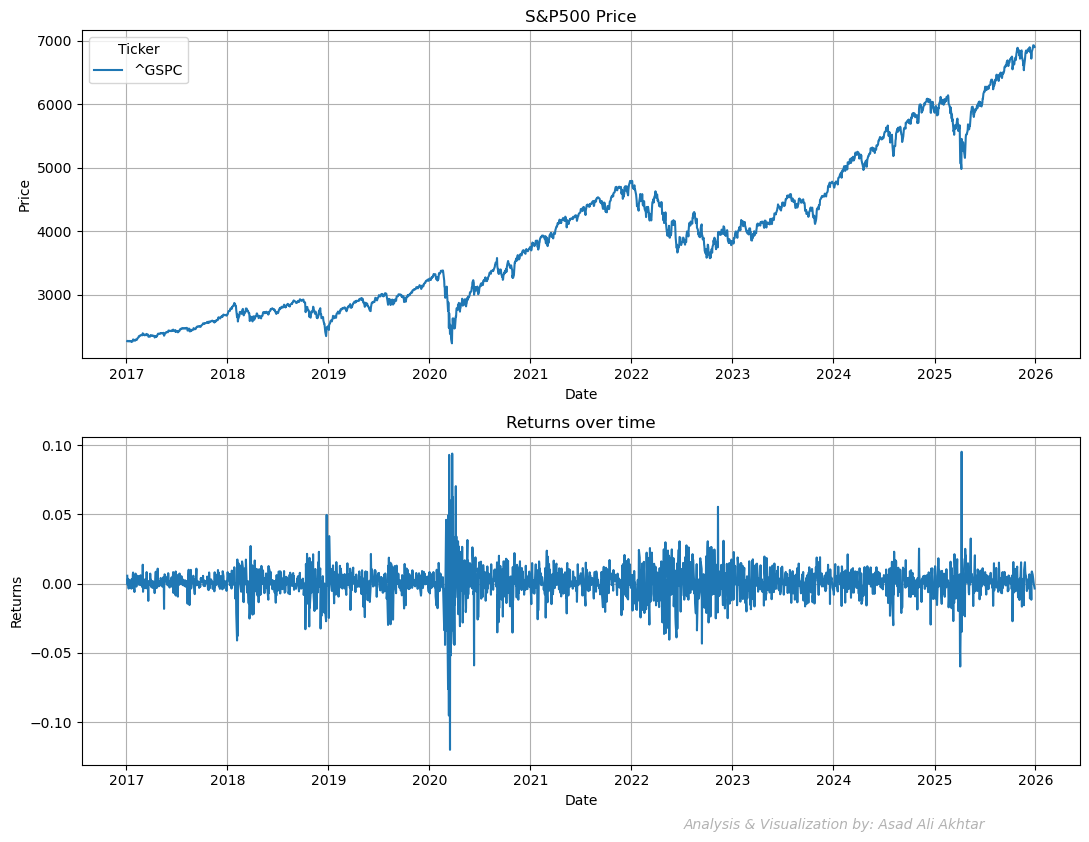

In [6]:
#plotting Price and Return of S&P500
fig, ax = plt.subplots(2, 1, figsize=(11, 9))

sns.lineplot(df['Close'], ax=ax[0])
ax[0].set_title('S&P500 Price')
ax[0].set_ylabel('Price')
ax[0].grid();

sns.lineplot(df['ret'], ax=ax[1])
ax[1].set_title('Returns over time')
ax[1].set_ylabel('Returns')
ax[1].grid();

plt.savefig('Price and Return Plot.jpg')

#--------------------------WaterMarking-------------------------------
fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
         fontsize=10, 
         color='gray', 
         ha='right', 
         va='bottom', 
         alpha=0.6, 
         fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

Looking at the *price chart*, we can observe the S&P 500's journey over our analysis period.<br> The index shows a **general upward trend** from around 2,300 points in early 2017 to nearly 7,000 by late 2025. However, this growth hasn't been smooth - there are several notable events visible in the chart:
<ul>
    <li><b>Early 2020:</b> A <i>sharp drop</i> coinciding with the <i>COVID-19 pandemic crash</i>, where the index fell from around 3,400 to approximately 2,200  in a matter of weeks</li>
    <li><b>2020-2021:</b> A strong <i>recovery period</i> following the crash, with the index reaching new highs</li>
    <li><b>2022:</b> A noticeable pullback as markets dealt with <i>inflation</i> concerns and <i>rising interest rates</i></li>
    <li><b>2024-2025:</b> Another <i>strong rally</i> pushing the index to new highs around 7,000</li>
</ul>

For a better risk and return comparison of the asset in question, it's better to check the annual return as well. As *risk/volatility* and *returns* are measured annually.<br>
**Annulized Return**
$$
    Annualized \ Return  = (1 + \mu_{daily})^{252} - 1
$$
Now I'll compute the risk for the S&P500 using historical data.<br>
**Annualized Risk/Volatility**
$$
    Annualized \ Risk = \sigma_{daily} * \sqrt{252}
$$

In [7]:
#computing annualized return
annualized_return = df['ret'].mean() * 252
print(f'Annualized Return of S&P500: {annualized_return*100:.2f}%')

#Computing Risk
daily_risk = df['ret'].std()

#computing annualized risk
annualized_risk = df['ret'].std() * np.sqrt(252)

print(f'Daily Risk of S&P500: {daily_risk*100:.2f}%')
print(f'Annualized Risk/Volatility of S&P500: {annualized_risk*100:.2f}%')

Annualized Return of S&P500: 14.21%
Daily Risk of S&P500: 1.17%
Annualized Risk/Volatility of S&P500: 18.62%


The S&P500 has delivered an **annualized return of 14.21%** over the period from 2017 to 2025. However, returns never come without risk.<br> The S&P500 has an **annual risk of 18.62%** for the same period.

While our earlier calculation provided an overall annualized risk of *18.62%*, this single number doesn't tell us how risk has evolved throughout our analysis period.<br> Risk in financial markets isn't constant; it changes over time.<br>
To capture this dynamic nature of risk, I'll calculate a **30-day rolling volatility** and plot it with returns.

In [8]:
#computing rolling volatility of 1.5 months of trading days
df['rolling_std30'] = df['ret'].rolling(window=30).std() * np.sqrt(252)

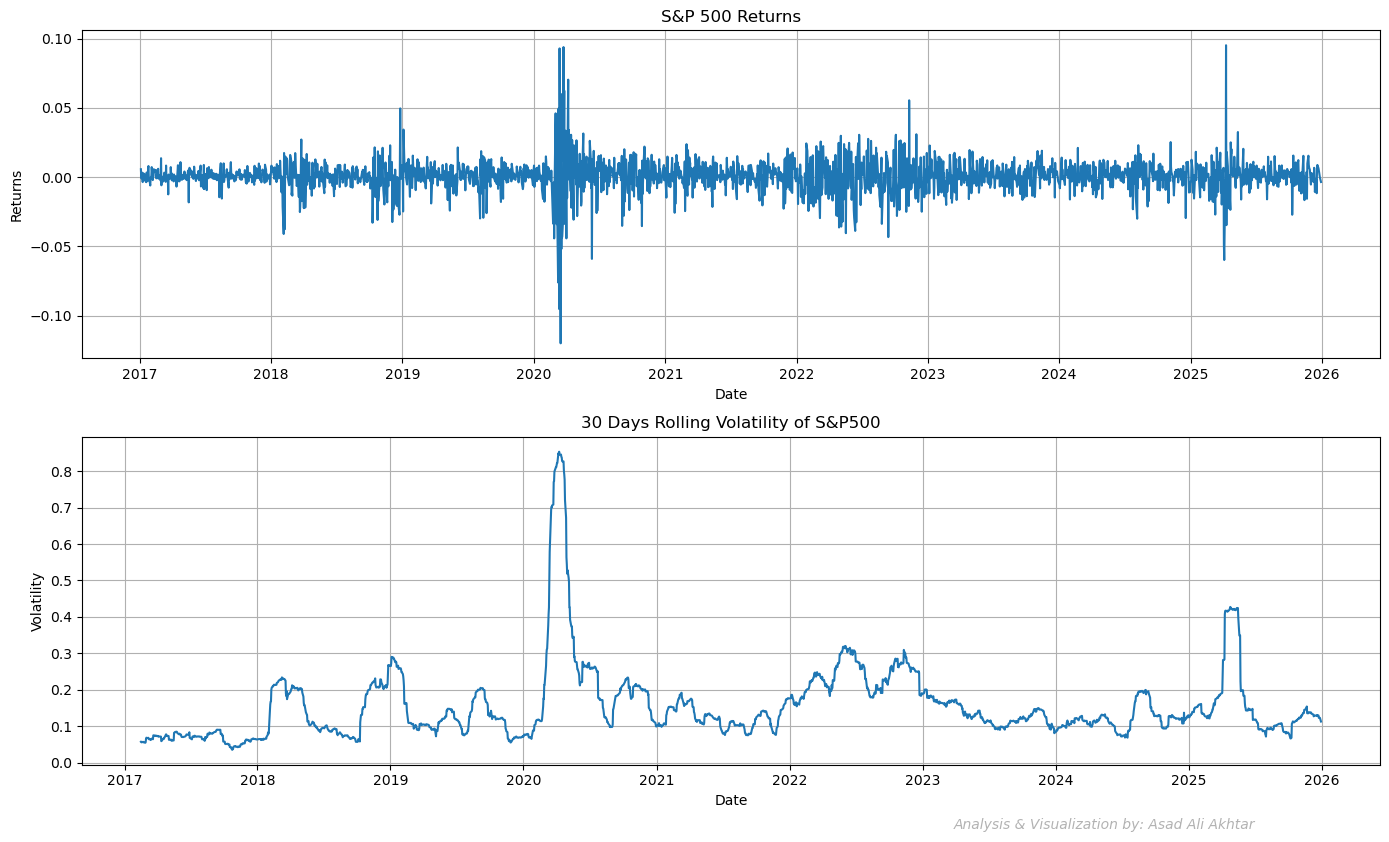

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(14,9))

#plotting return
sns.lineplot(df['ret'], ax=ax[0])
ax[0].set_title('S&P 500 Returns')
ax[0].set_ylabel('Returns')
ax[0].grid();

#plotting rolling volatility
sns.lineplot(df['rolling_std30'], ax=ax[1])
ax[1].set_title('30 Days Rolling Volatility of S&P500')
ax[1].set_ylabel('Volatility')
ax[1].grid();

plt.savefig('Return and Volatility Plot.jpg')


#--------------------------WaterMarking-------------------------------
fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
         fontsize=10, 
         color='gray', 
         ha='right', 
         va='bottom', 
         alpha=0.6, 
         fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

The rolling volatility chart reveals that market risk is far from constant. During normal market conditions, the S&P 500's volatility typically ranges between **10-15%** annually.<br> However, during crisis periods, particularly the *COVID-19 crash* in March 2020, volatility can explode to **80-90%**, making the market nearly *six times riskier* than usual.

The volatility gives us a general sense of how much an asset's returns fluctuate, it doesn't specifically tell us about the downside risk.<br>
For that, we'll need to compute **Value at Risk (VaR)**. I'll be using the **historical simulation method** to compute *95%* and *99% daily VaR*.

In [10]:
#computing 95% VaR
var_95 = df['ret'].quantile(0.05)

#computing 99% VaR
var_99 = df['ret'].quantile(0.01)

print(f'Historical VaR (95%): {var_95:.2%}')
print(f'Historical VaR (99%): {var_99:.2%}')

Historical VaR (95%): -1.73%
Historical VaR (99%): -3.37%


The calculations show the potential losses we might face on bad days:

<ul>
    <li>
        <b>95% VaR</b>: -1.73% - On most days (95 out of 100), our daily loss will <i>stay below</i> <b>1.73%</b>. Only on roughly 1 out of every 20 trading days (about once a month) should we expect losses larger than this.
    </li>
    <li>
    <b>99% VaR</b>: -3.37% - This captures the really bad days. Only <i>1%<i> of the time (roughly 2-3 days per year) will we see losses exceeding <b>3.37%</b>.
    </li>
</ul>